# Radial Basic Function Neural Network

In [1]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
import keras
from keras import layers
import tensorflow
from rbf_keras import kmeans_initializer
from keras.optimizers import RMSprop
from rbf_keras import rbflayer
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
housing_price = pd.read_csv('./housing_price_dataset.csv')
housing_price.head(10)

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065
5,2095,2,3,Suburb,2020,198208.803907
6,2724,2,1,Suburb,1993,343429.319110
7,2044,4,3,Rural,1957,184992.321268
8,2638,4,3,Urban,1959,377998.588152
9,1121,5,2,Urban,2004,95961.926014


In [ ]:
print(housing_price.isnull().sum(),"\n\n")
print("The rows number", housing_price.shape[0])

In [ ]:
housing_price.Neighborhood.value_counts().plot(kind='barh')

In [ ]:
housing_price.Bathrooms.value_counts().plot(kind='barh')

In [3]:
neighborhood = pd.get_dummies(housing_price.Neighborhood)

In [4]:
df = pd.concat([housing_price[['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt']].copy(), neighborhood.copy(), housing_price.Price.copy()], axis=1)

In [5]:
scaler = MinMaxScaler((0,1))
df['SquareFeet'] = scaler.fit_transform(df[['SquareFeet']])
df['Bedrooms'] = scaler.fit_transform(df[['Bedrooms']])
df['Bathrooms'] = scaler.fit_transform(df[['Bathrooms']])
df['YearBuilt'] = scaler.fit_transform(df[['YearBuilt']])
df['Price'] = scaler.fit_transform(df[['Price']])

In [6]:
x = df.iloc[:, :-1]
y = df.iloc[:, 7]

In [7]:
x.head()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Rural,Suburb,Urban
0,0.563282,0.666667,0.0,0.267606,1,0,0
1,0.729865,0.333333,0.5,0.422535,1,0,0
2,0.430215,0.000000,0.0,0.281690,0,1,0
3,0.647324,0.000000,0.0,0.647887,0,0,1
4,0.565283,1.000000,0.5,0.718310,0,1,0


In [21]:
# kfold = KFold(n_splits=2)
# histories = []

# for train_index, test_index in kfold.split(x):
#     X_train, X_test = x.iloc[train_index], x.iloc[test_index]
#     Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]
X_train, X_test = x.iloc[:40000], x.iloc[40000:]
Y_train, Y_test = y.iloc[:40000], y.iloc[40000:]

rbfLayer = rbflayer.RBFLayer(50,
                                 initializer=kmeans_initializer.InitCentersKMeans(x),
                                 betas=1.0,
                                 input_shape=([7]))
    
model = keras.models.Sequential()
model.add(rbfLayer)
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(loss='mae', 
              optimizer=RMSprop(),
              metrics=[keras.metrics.MeanAbsoluteError()])
    
model.fit(X_train, Y_train, epochs=50, batch_size=16)

c:\Users\colit\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Epoch 1/50
2500/2500 [==============================] - 5s 2ms/step - loss: 0.0814 - mean_absolute_error: 0.0814
Epoch 2/50
2500/2500 [==============================] - 5s 2ms/step - loss: 0.0771 - mean_absolute_error: 0.0771
Epoch 3/50
2500/2500 [==============================] - 5s 2ms/step - loss: 0.0769 - mean_absolute_error: 0.0769
Epoch 4/50
2500/2500 [==============================] - 5s 2ms/step - loss: 0.0769 - mean_absolute_error: 0.0769
Epoch 5/50
2500/2500 [==============================] - 5s 2ms/step - loss: 0.0768 - mean_absolute_error: 0.0768
Epoch 6/50
2500/2500 [==============================] - 5s 2ms/step - loss: 0.0767 - mean_absolute_error: 0.0767
Epoch 7/50
2500/2500 [==============================] - 5s 2ms/step - loss: 0.0767 - mean_absolute_error: 0.0767
Epoch 8/50
2500/2500 [==============================] - 5s 2ms/step - loss: 0.0766 - mean_absolute_error: 0.0766
Epoch 9/50
2500/2500 [==============================] - 5s 2ms/step - loss: 0.0765 - mean_absolu

In [22]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rbf_layer_2 (RBFLayer)      (None, 50)                400       
                                                                 
 dense_2 (Dense)             (None, 1)                 51        
                                                                 
Total params: 451 (1.76 KB)
Trainable params: 451 (1.76 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [23]:
loss, accuracy = model.evaluate(X_test, Y_test, batch_size=16)

625/625 [==============================] - 1s 2ms/step - loss: 0.0758 - mean_absolute_error: 0.0758


In [24]:
predictions = model.predict(X_test[9800:], batch_size=16)

13/13 [==============================] - 0s 1ms/step


In [25]:
X_test[9800:]

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Rural,Suburb,Urban
49800,0.174587,0.333333,0.0,0.605634,0,1,0
49801,0.157579,0.000000,0.5,0.957746,0,0,1
49802,0.870435,1.000000,0.0,0.859155,1,0,0
49803,0.471236,0.000000,1.0,0.845070,0,0,1
49804,0.972486,0.333333,0.5,0.112676,0,0,1
...,...,...,...,...,...,...,...
49995,0.141071,1.000000,1.0,0.352113,1,0,0
49996,0.927464,0.000000,0.5,0.535211,0,1,0
49997,0.989995,1.000000,1.0,0.169014,0,1,0
49998,0.798399,1.000000,0.5,0.478873,1,0,0


In [26]:
actual_price = housing_price.Price

In [27]:
actual_price = np.array(actual_price)
actual_price = actual_price.reshape(-1)
test_actual_price = actual_price[49800:]
test_actual_price

array([139739.86588618, 207922.72785062, 313492.68439862, 270903.12814468,
       250853.73081412, 376066.067519  , 288672.22062534, 270563.86533454,
       192604.55377025, 151410.30645205, 295277.55848913, 265399.84558942,
       275366.60130076, 316678.50623396, 260083.86608124, 202194.03311472,
       315253.75354169, 242332.51947275, 172828.09027132, 324706.25590404,
       147635.41256908, 179040.7748712 , 212211.82444221, 117246.46154526,
       230809.19893774,  60059.81740317, 230938.66917067, 122801.23152237,
        98231.91587561, 206365.50885737, 361884.81031627, 107360.74944117,
       244086.99909647, 245920.44807033, 151903.08673292, 237327.89663682,
       213084.56982879, 264129.28444507, 104786.03119892,  85030.62992504,
       324158.53842765, 238467.60198162, 292434.75184349, 272494.16430775,
       330649.80192909, 322532.66532692, 157693.37954435, 338938.31145658,
       285656.14306901, 255177.89919827, 190971.14859546, 113032.0080367 ,
       101482.01581429, 3

In [28]:
def price_denormalization(predictions, original_data):
    original_data = np.array(original_data)
    maximum = np.max(original_data)
    minimum = np.min(original_data)
    denorm_predict = []
    for pred in predictions:
        den_predict = pred * (maximum - minimum) + minimum
        denorm_predict.append(den_predict)
    
    return np.array(denorm_predict)


In [29]:
predictions = np.array(predictions)
predictions = predictions.reshape(-1)
predictions = price_denormalization(predictions, housing_price.Price)
predictions

array([151272.37454351, 145712.95517277, 294264.46766824, 204488.0505286 ,
       311867.96666877, 269318.79959111, 269760.58667148, 209149.14533882,
       185316.81726505, 187369.06118727, 210906.88555276, 272888.36481815,
       272187.50020331, 296107.35361933, 188793.71972429, 174453.7939504 ,
       307975.15336465, 175716.67085914, 248009.79845281, 311696.88724576,
       186301.13854732, 255536.25297273, 162016.95340871, 206598.96511146,
       255688.54769858, 165846.44715483, 295148.60915205, 148454.44934591,
       124086.15856245, 155138.35031471, 202263.54526031, 198361.85965377,
       285635.86201659, 285718.34448711, 179289.05694255, 166689.44195722,
       201089.58048353, 227052.72672447, 157613.89604066, 182694.08272085,
       259612.09100223, 136799.94731525, 292630.76633957, 220329.31800757,
       288814.41557787, 277821.93229085, 190458.41895505, 249886.09342903,
       273630.01365801, 229307.14252563, 188213.78947682, 150266.27435902,
       126129.24652071, 1

In [30]:
result_df = pd.DataFrame(data={'predictions':predictions, 'actuals':test_actual_price})

<Axes: >

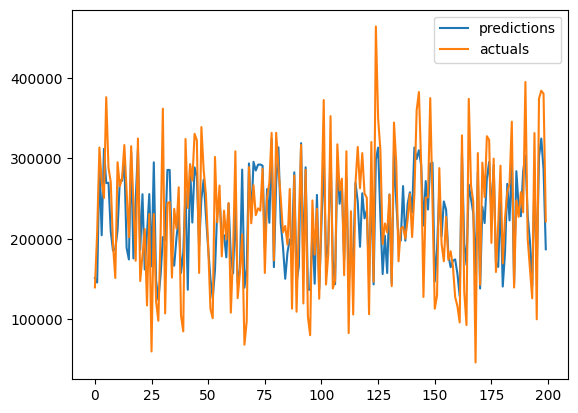

In [31]:
result_df.plot()